<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
 LD-PLSM Modeling and Comaprison with & without Environmental Parameters
</p>

In [66]:
import numpy as np                                           # For numerical operations
import pandas as pd                                          # For data manipulation and analysis
import matplotlib.pyplot as plt                              # For plotting and visualizations
import seaborn as sns                                        # For enhanced data visualizations
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import MaxNLocator                    # For controlling y-axis ticks
from sklearn.metrics import mean_squared_error, r2_score     # For model evaluation metrics
from sklearn.model_selection import KFold, train_test_split  # For splitting data and cross-validation
from scipy.optimize import curve_fit                         # For curve fitting and optimization                       # For formula-based statistical modeling

In [67]:
# Define the path to the dataset
dataset_path = '../all_data_files/cleaned_dataset_per_device.csv'

# Load the dataset
try:
    df = pd.read_csv(dataset_path)
    print("\nDataset loaded successfully.\n")
except FileNotFoundError:
    print(f"File not found at the specified path: {dataset_path}")
    import sys
    sys.exit()


Dataset loaded successfully.



<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Data Preparation and Single Train-Test Split
</p>

In [68]:
# Extract the device_id column
device_id_all = df['device_id'].values

# Existing features and target
all_features = np.column_stack((
    df['distance'].values, 
    df['frequency'].values, 
    df['c_walls'].values, 
    df['w_walls'].values, 
    df['co2'].values, 
    df['humidity'].values,
    df['pm25'].values, 
    df['pressure'].values, 
    df['temperature'].values, 
    df['snr'].values
))
PL_all = df['exp_pl'].values
time_all = df['time'].values
indices = np.arange(len(df))

# Use stratify to ensure the distribution of device IDs is preserved.
X_train_all, X_test_all, PL_train_all, PL_test_all, time_train, time_test, train_idx, test_idx = train_test_split(
    all_features,
    PL_all,
    time_all,
    indices,
    test_size=0.2,
    random_state=200,
    shuffle=True,
    stratify=device_id_all  # To ensure each device is represented in both splits.
)

# Sort the training set by time and overwrite the original variable names:
order_train = np.argsort(time_train)
time_train   = time_train[order_train]
X_train_all  = X_train_all[order_train]
PL_train_all = PL_train_all[order_train]
train_idx    = train_idx[order_train]

# Sort the test set by time and overwrite the original variable names:
order_test = np.argsort(time_test)
time_test   = time_test[order_test]
X_test_all  = X_test_all[order_test]
PL_test_all = PL_test_all[order_test]
test_idx    = test_idx[order_test]

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Analyzing Temporal Distribution in Training and Testing Sets
</p>

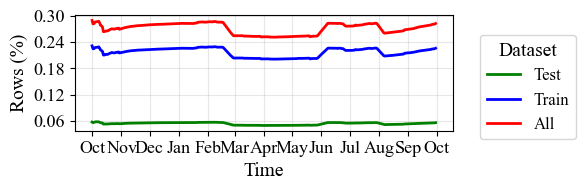

In [69]:
# Convert timestamp to datetime with explicit ISO8601 format
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# Reuse the same train/test indices
train_indices = train_idx
test_indices  = test_idx

def calculate_percentage(indices, total_len, window=100):
    # Group by date using the 'time' column and count records
    daily_counts = df.iloc[indices].groupby(df.iloc[indices]['time'].dt.date).size()
    # Convert to percentage
    percentages = (daily_counts / total_len * 100).rename_axis('date')
    # Reindex to ensure continuity across dates and apply rolling mean
    full_range = pd.date_range(start=percentages.index.min(), end=percentages.index.max())
    return (percentages.reindex(full_range, fill_value=0)
                       .sort_index()
                       .rolling(window, min_periods=1)
                       .mean())

total_len = len(df)
train_percentages = calculate_percentage(train_indices, total_len)
test_percentages  = calculate_percentage(test_indices, total_len)
whole_percentages = calculate_percentage(indices, total_len)

fig, ax = plt.subplots(figsize=(6, 2))
ax.grid(True, alpha=0.3)

for data, color, label in [(test_percentages, 'green', 'Test'),
                           (train_percentages, 'blue', 'Train'),
                           (whole_percentages, 'red', 'All')]:
    ax.plot(data.index, data.values, color=color, label=label, linewidth=2)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Rows (%)', fontsize=14)

# Adjust the legend position to the right of the plot
ax.legend(title='Dataset', title_fontsize=14, fontsize=12,
          bbox_to_anchor=(1.05, 0.9), loc='upper left')

# Adjust x-axis formatting with year in front of the month
ax.xaxis.set_major_locator(MonthLocator())
ax.xaxis.set_major_formatter(DateFormatter('%b'))

ax.tick_params(axis='both', which='major', labelsize=13, direction='out')

# Adjust the y-axis ticks to include more scale values
ax.yaxis.set_major_locator(MaxNLocator(nbins=5, prune=None)) 

plt.tight_layout()

# Save the figure to the specified directory with 1000 dpi
#plt.savefig('../all_data_files/Observations_Over_Time.png', dpi=1000)
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Defining LDPLM-MW Model, Fitting, and Extracting Parameters
</p>

In [70]:
# Indices for features used in LDPLM-MW
idx_mw = [0, 2, 3]  # Indices of d_all, c_walls_all, w_walls_all in all_features

# Extract training and testing data for LDPLM-MW
x_train_mw = X_train_all[:, idx_mw].T  # Transpose to match original shape
x_test_mw = X_test_all[:, idx_mw].T
PL_train_mw = PL_train_all
PL_test_mw = PL_test_all

# Define the Log-Distance Path Loss Model with Multi-Wall alone
def log_distance_path_loss_separate_walls(x, PL_d0, n, L_c, L_w):
    d, c_walls, w_walls = x
    d0 = 1  # Reference distance in meters
    return (PL_d0 + 10 * n * np.log10(d / d0) + c_walls * L_c + w_walls * L_w)

# Initial guesses for PL_d0, n, L_c, and L_w
initial_guesses_mw = [40, 3.5, 12, 5]  # Can be adjusted

# Perform curve fitting for LDPLM-MW
popt_mw, pcov_mw = curve_fit(
    log_distance_path_loss_separate_walls,
    x_train_mw,
    PL_train_mw,
    p0=initial_guesses_mw,
    maxfev=100000
)

# Extract the fitted parameters for LDPLM-MW
PL_d0_mw, n_mw, L_c_mw, L_w_mw = popt_mw

# Predict path loss for the test set
PL_pred_mw = log_distance_path_loss_separate_walls(x_test_mw, PL_d0_mw, n_mw, L_c_mw, L_w_mw)

# Calculate the shadowing component for the training set
PL_train_pred_mw = log_distance_path_loss_separate_walls(x_train_mw, PL_d0_mw, n_mw, L_c_mw, L_w_mw)
shadowing_train_mw = PL_train_mw - PL_train_pred_mw
sigma_mw = np.std(shadowing_train_mw)

# Calculate RMSE and R-squared for LDPLM-MW on Test Set
rmse_mw = np.sqrt(mean_squared_error(PL_test_mw, PL_pred_mw))
r_squared_mw = r2_score(PL_test_mw, PL_pred_mw)

# Calculate RMSE and R-squared for LDPLM-MW on Training Set
rmse_train_mw = np.sqrt(mean_squared_error(PL_train_mw, PL_train_pred_mw))
r_squared_train_mw = r2_score(PL_train_mw, PL_train_pred_mw)

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Defining COST 231 MWM (Calibrated by Regression), Fitting, and Extracting Parameters
</p>

In [71]:
# Indices for features used in COST 231 MWM
idx_cost = [0, 1, 2, 3]  # Indices of d_all, frequency_all, c_walls_all, w_walls_all in all_features

# Extract training and testing data for COST 231 MWM
x_train_cost = X_train_all[:, idx_cost].T
x_test_cost = X_test_all[:, idx_cost].T
PL_train_cost = PL_train_all
PL_test_cost = PL_test_all

# Define the COST 231 Multi-Wall Model: free-space loss + constant loss + wall losses
# (one floor, so the COST 231 floor term is zero); calibrated by regression on the training set
def cost231_multi_wall(x, L_const, L_c, L_w):
    d, frequency, c_walls, w_walls = x
    L_FS = 20 * np.log10(4 * np.pi * d * frequency * 1e6 / 299792458)  # free-space loss, frequency in MHz
    return L_FS + L_const + c_walls * L_c + w_walls * L_w

# Initial guesses for L_const, L_c, and L_w (COST 231 values: 0 dB, heavy wall 6.9 dB, light wall 3.4 dB)
initial_guesses_cost = [0, 6.9, 3.4]

# Perform curve fitting for COST 231 MWM
popt_cost, pcov_cost = curve_fit(
    cost231_multi_wall,
    x_train_cost,
    PL_train_cost,
    p0=initial_guesses_cost,
    maxfev=100000
)

# Extract the fitted parameters for COST 231 MWM
L_const_cost, L_c_cost, L_w_cost = popt_cost

# Predict path loss for the test set
PL_pred_cost = cost231_multi_wall(x_test_cost, L_const_cost, L_c_cost, L_w_cost)

# Calculate the shadowing component for the training set
PL_train_pred_cost = cost231_multi_wall(x_train_cost, L_const_cost, L_c_cost, L_w_cost)
shadowing_train_cost = PL_train_cost - PL_train_pred_cost
sigma_cost = np.std(shadowing_train_cost)

# Calculate RMSE and R-squared for COST 231 MWM on Test Set
rmse_cost = np.sqrt(mean_squared_error(PL_test_cost, PL_pred_cost))
r_squared_cost = r2_score(PL_test_cost, PL_pred_cost)

# Calculate RMSE and R-squared for COST 231 MWM on Training Set
rmse_train_cost = np.sqrt(mean_squared_error(PL_train_cost, PL_train_pred_cost))
r_squared_train_cost = r2_score(PL_train_cost, PL_train_pred_cost)

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Defining LDPLM-MW-EP Model, Fitting, and Extracting Parameters
</p>

In [72]:
# Indices for features used in LDPLM-MW-EP
idx_ep = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# Extract training and testing data for LDPLM-MW-EP
x_train_ep = X_train_all[:, idx_ep].T
x_test_ep = X_test_all[:, idx_ep].T
PL_train_ep = PL_train_all
PL_test_ep = PL_test_all

# Define the enhanced Log-Distance Path Loss Model with Environmental Parameters
def log_distance_path_loss_with_env_params(x, PL_d0, n, L_c, L_w, a_co2, a_hum, a_pm25, a_pres, a_temp, k_snr):
    d, frequency, c_walls, w_walls, co2, humidity, pm25, pressure, temperature, snr = x
    d0 = 1  # Reference distance in meters
    return (PL_d0 + 10 * n * np.log10(d / d0) + 20 * np.log10(frequency) + c_walls * L_c + w_walls * L_w +
            a_co2 * co2 + a_hum * humidity + a_pm25 * pm25 +
            a_pres * pressure + a_temp * temperature + snr * k_snr)

# Initial guesses for PL_d0, n, L_c, L_w, environmental factors, and SNR coefficient
initial_guesses_ep = [40, 3.5, 12, 5, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0]  # Can be adjusted

# Perform curve fitting for LDPLM-MW-EP
popt_ep, pcov_ep = curve_fit(
    log_distance_path_loss_with_env_params,
    x_train_ep,
    PL_train_ep,
    p0=initial_guesses_ep,
    maxfev=100000
)

# Extract the fitted parameters for LDPLM-MW-EP
PL_d0_ep, n_ep, L_c_ep, L_w_ep, a_co2_ep, a_hum_ep, a_pm25_ep, a_pres_ep, a_temp_ep, k_snr_ep = popt_ep

# Predict path loss for the test set
PL_pred_ep = log_distance_path_loss_with_env_params(
    x_test_ep, PL_d0_ep, n_ep, L_c_ep, L_w_ep, a_co2_ep, a_hum_ep, a_pm25_ep, a_pres_ep, a_temp_ep, k_snr_ep
)

# Calculate the shadowing component for the training set
PL_train_pred_ep = log_distance_path_loss_with_env_params(
    x_train_ep, PL_d0_ep, n_ep, L_c_ep, L_w_ep, a_co2_ep, a_hum_ep, a_pm25_ep, a_pres_ep, a_temp_ep, k_snr_ep
)
shadowing_train_ep = PL_train_ep - PL_train_pred_ep
sigma_ep = np.std(shadowing_train_ep)

# Calculate RMSE and R-squared for LDPLM-MW-EP on Test Set
rmse_ep = np.sqrt(mean_squared_error(PL_test_ep, PL_pred_ep))
r_squared_ep = r2_score(PL_test_ep, PL_pred_ep)

# Calculate RMSE and R-squared for LDPLM-MW-EP on Training Set
rmse_train_ep = np.sqrt(mean_squared_error(PL_train_ep, PL_train_pred_ep))
r_squared_train_ep = r2_score(PL_train_ep, PL_train_pred_ep)

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Comparing Parameters and Metrics for the two Models
</p>

In [73]:
# Parameters Comparison
params_cost = {
    'Constant loss (L_const) [dB]': L_const_cost,
    'Path loss exponent (n)': 2,  # fixed by the free-space term
    'Brick Wall Loss (L_c) [dB]': L_c_cost,
    'Wood Wall Loss (L_w) [dB]': L_w_cost
}

params_mw = {
    'PL(d0) [dB]': PL_d0_mw,
    'Path loss exponent (n)': n_mw,
    'Brick Wall Loss (L_c) [dB]': L_c_mw,
    'Wood Wall Loss (L_w) [dB]': L_w_mw
}

params_ep = {
    'PL(d0) [dB]': PL_d0_ep,
    'Path loss exponent (n)': n_ep,
    'Brick Wall Loss (L_c) [dB]': L_c_ep,
    'Wood Wall Loss (L_w) [dB]': L_w_ep,
    'CO2 coefficient (a_co2) [dB/unit]': a_co2_ep,
    'Humidity coefficient (a_hum) [dB/unit]': a_hum_ep,
    'PM2.5 coefficient (a_pm25) [dB/unit]': a_pm25_ep,
    'Pressure coefficient (a_pres) [dB/unit]': a_pres_ep,
    'Temperature coefficient (a_temp) [dB/unit]': a_temp_ep,
    'SNR scaling factor (k_snr)': k_snr_ep
}

# Create the Parameter list: the constant loss of the COST 231 MWM + all LDPLM-MW-EP parameters
parameter_list = ['Constant loss (L_const) [dB]'] + list(params_ep)

# Construct the DataFrame: each model shows its own parameters and '-' for the others
params_df = pd.DataFrame({
    'Parameter': parameter_list,
    'COST 231 MWM': [params_cost.get(param, '-') for param in parameter_list],
    'LDPLM-MW': [params_mw.get(param, '-') for param in parameter_list],
    'LDPLM-MW-EP': [params_ep.get(param, '-') for param in parameter_list]
})

print("\n=== Table of Parameters to be Compared ===\n")
display(params_df)

# Metrics Comparison Including Training and Test Sets 
# Metrics Comparison
metrics = [
    'RMSE (Train) [dB]', 
    'RMSE (Test) [dB]', 
    'R-squared (Train)', 
    'R-squared (Test)', 
    'Shadowing σ (dB)'
]
metrics_values = {
    'COST 231 MWM': [rmse_train_cost, rmse_cost, r_squared_train_cost, r_squared_cost, sigma_cost],
    'LDPLM-MW': [rmse_train_mw, rmse_mw, r_squared_train_mw, r_squared_mw, sigma_mw],
    'LDPLM-MW-EP': [rmse_train_ep, rmse_ep, r_squared_train_ep, r_squared_ep, sigma_ep]
}

metrics_df = pd.DataFrame(metrics_values, index=metrics)

print("\n=== Performance Metrics Comparison ===\n")
display(metrics_df)

# Where the improvement comes from: one step at a time (test RMSE)
print("\n=== Gain of each modelling step (test RMSE) ===\n")
print(f"COST 231 MWM -> LDPLM-MW   (fitted distance exponent instead of free space): {rmse_cost - rmse_mw:.2f} dB")
print(f"LDPLM-MW -> LDPLM-MW-EP    (environmental parameters and SNR):              {rmse_mw - rmse_ep:.2f} dB")


=== Table of Parameters to be Compared ===



,Parameter,COST 231 MWM,LDPLM-MW,LDPLM-MW-EP
0,Constant loss (L_const) [dB],13.147981,-,-
1,PL(d0) [dB],-,16.950998,-33.197054
2,Path loss exponent (n),2,4.910973,4.877135
3,Brick Wall Loss (L_c) [dB],10.764307,7.044509,7.114184
4,Wood Wall Loss (L_w) [dB],5.191129,1.126627,1.124907
5,CO2 coefficient (a_co2) [dB/unit],-,-,-0.003006
6,Humidity coefficient (a_hum) [dB/unit],-,-,-0.101099
7,PM2.5 coefficient (a_pm25) [dB/unit],-,-,-0.032056
8,Pressure coefficient (a_pres) [dB/unit],-,-,0.0048
9,Temperature coefficient (a_temp) [dB/unit],-,-,-0.140723



=== Performance Metrics Comparison ===



,COST 231 MWM,LDPLM-MW,LDPLM-MW-EP
RMSE (Train) [dB],6.827763,5.935689,5.874298
RMSE (Test) [dB],6.829073,5.939196,5.876646
R-squared (Train),0.844012,0.882110,0.884536
R-squared (Test),0.843837,0.881884,0.884359
Shadowing σ (dB),6.827763,5.935689,5.874298



=== Gain of each modelling step (test RMSE) ===

COST 231 MWM -> LDPLM-MW   (fitted distance exponent instead of free space): 0.89 dB
LDPLM-MW -> LDPLM-MW-EP    (environmental parameters and SNR):              0.06 dB


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Plotting some comparison Parameters and Metrics for the two Models
</p>

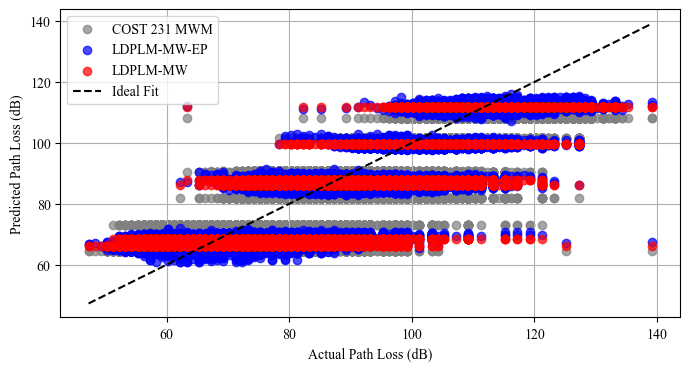

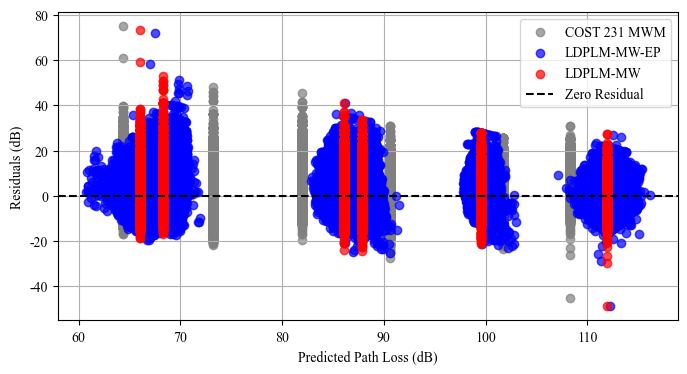

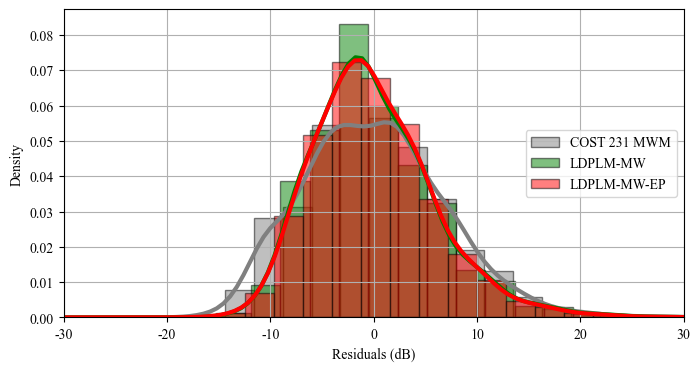


Residual Distribution Values:

COST 231 MWM: Mean: 0.014 dB, Skewness: 0.4197
LDPLM-MW: Mean: 0.014 dB, Skewness: 0.8041
LDPLM-MW-EP: Mean: 0.0127 dB, Skewness: 0.7433


In [74]:
# -------------------------------
# Section 4: 
# -------------------------------

# Step 15: Plot Actual vs Predicted Path Loss
plt.figure(figsize=(8, 4))
# Plot COST 231 MWM at the back in gray
plt.scatter(PL_test_cost, PL_pred_cost, alpha=0.7, label='COST 231 MWM', color='gray', zorder=1)
# Plot LDPLM-MW-EP first in blue
plt.scatter(PL_test_ep, PL_pred_ep, alpha=0.7, label='LDPLM-MW-EP', color='blue', zorder=2)
# Plot LDPLM-MW last in red to appear in foreground
plt.scatter(PL_test_mw, PL_pred_mw, alpha=0.7, label='LDPLM-MW', color='red', zorder=3)
# Ideal Fit Line in black, highest zorder to appear on top
min_PL = min(PL_test_mw.min(), PL_test_ep.min(), PL_pred_mw.min(), PL_pred_ep.min(), PL_pred_cost.min())
max_PL = max(PL_test_mw.max(), PL_test_ep.max(), PL_pred_mw.max(), PL_pred_ep.max(), PL_pred_cost.max())
plt.plot(
    [min_PL, max_PL],
    [min_PL, max_PL],
    'k--', label='Ideal Fit', zorder=4
)
plt.xlabel('Actual Path Loss (dB)')
plt.ylabel('Predicted Path Loss (dB)')
# plt.title('Actual vs Predicted Path Loss Comparison')
plt.legend(loc='upper left')
plt.grid(True)
#plt.savefig('../all_data_files/Actual_vs_Predicted.png', dpi=1000)
plt.show()

# Step 16: Residual Analysis - Residuals vs Predicted Path Loss
residuals_mw = PL_test_mw - PL_pred_mw
residuals_ep = PL_test_ep - PL_pred_ep
residuals_cost = PL_test_cost - PL_pred_cost

plt.figure(figsize=(8, 4))
# Plot COST 231 MWM residuals at the back in gray
plt.scatter(PL_pred_cost, residuals_cost, alpha=0.7, label='COST 231 MWM', color='gray', zorder=1)
# Plot LDPLM-MW-EP residuals first in blue
plt.scatter(PL_pred_ep, residuals_ep, alpha=0.7, label='LDPLM-MW-EP', color='blue', zorder=2)
# Plot LDPLM-MW residuals last in red to appear in foreground
plt.scatter(PL_pred_mw, residuals_mw, alpha=0.7, label='LDPLM-MW', color='red', zorder=3)
# Horizontal line at zero in black, highest zorder to appear on top
plt.axhline(0, color='k', linestyle='--', label='Zero Residual', zorder=4)
plt.xlabel('Predicted Path Loss (dB)')
plt.ylabel('Residuals (dB)')
# plt.title('Residuals vs Predicted Path Loss Comparison')
plt.legend(loc='upper right')
plt.grid(True)
plt.savefig('../all_data_files/Residuals_vs_Predicted.png', dpi=1000)
plt.show()

# Step 17: Residual Analysis - Histogram of Residuals with KDE and Smoothness Control
plt.figure(figsize=(8, 4))

# Plot histograms with density=True to normalize the counts
plt.hist(residuals_cost, bins=43, alpha=0.5, label='COST 231 MWM', color='gray', edgecolor='k', density=True)
plt.hist(residuals_mw, bins=43, alpha=0.5, label='LDPLM-MW', color='green', edgecolor='k', density=True)
plt.hist(residuals_ep, bins=43, alpha=0.5, label='LDPLM-MW-EP', color='red', edgecolor='k', density=True)

# KDE plots using Seaborn 
sns.kdeplot(residuals_cost, color='gray', bw_adjust=3, linewidth=3)
sns.kdeplot(residuals_mw, color='green', bw_adjust=3, linewidth=3)
sns.kdeplot(residuals_ep, color='red', bw_adjust=3, linewidth=3)

plt.xlabel('Residuals (dB)')
plt.ylabel('Density')  # Changed from 'Frequency' to 'Density' due to normalization
# plt.title('Histogram of Residuals Comparison')
plt.xlim(-30, 30)  # Set x-axis limits
plt.legend(loc='center right')
plt.grid(True)
#plt.savefig('../all_data_files/Histogram_of_Residuals_with_KDE.png', dpi=1000)
plt.show()

# Convert numpy arrays to pandas Series
residuals_mw = pd.Series(residuals_mw)
residuals_ep = pd.Series(residuals_ep)
residuals_cost = pd.Series(residuals_cost)

# Residual Distribution Values
resid_mean_mw = round(residuals_mw.mean(), 4)
resid_skew_mw = round(residuals_mw.skew(), 4)

resid_mean_ep = round(residuals_ep.mean(), 4)
resid_skew_ep = round(residuals_ep.skew(), 4)

resid_mean_cost = round(residuals_cost.mean(), 4)
resid_skew_cost = round(residuals_cost.skew(), 4)

print(f'\nResidual Distribution Values:')
print(f'\nCOST 231 MWM: Mean: {resid_mean_cost} dB, Skewness: {resid_skew_cost}')
print(f'LDPLM-MW: Mean: {resid_mean_mw} dB, Skewness: {resid_skew_mw}')
print(f'LDPLM-MW-EP: Mean: {resid_mean_ep} dB, Skewness: {resid_skew_ep}')

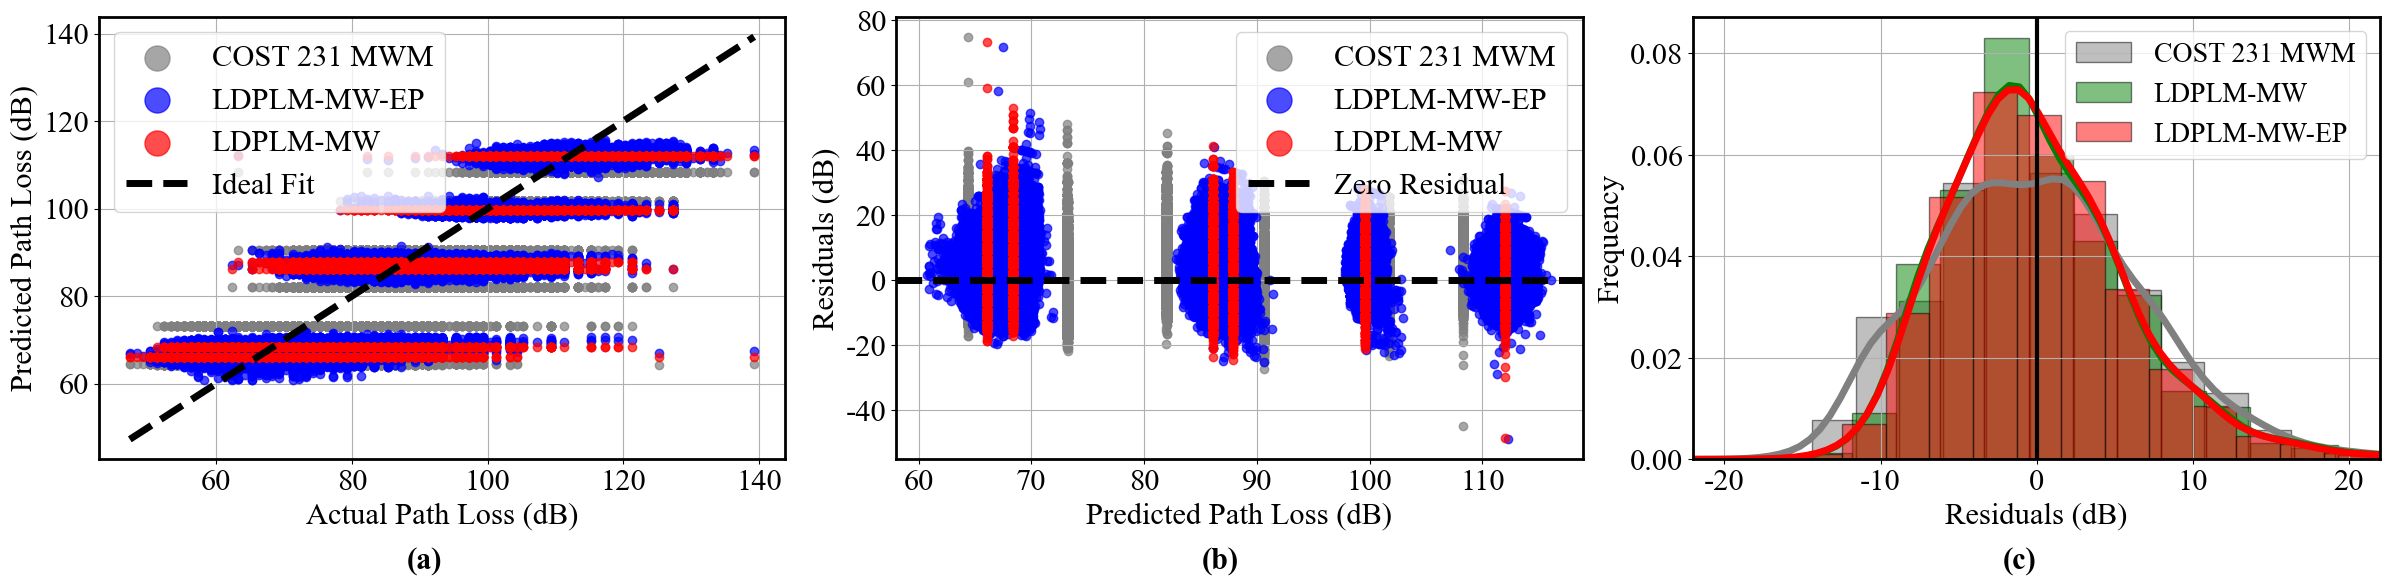


Residual Distribution Values:

COST 231 MWM: Mean: 0.014 dB, Skewness: 0.4197
LDPLM-MW: Mean: 0.014 dB, Skewness: 0.8041
LDPLM-MW-EP: Mean: 0.0127 dB, Skewness: 0.7433


In [75]:
# -------------------------------
# Section 4: Plotting (Re-arranging the plots for the manuscript)
# -------------------------------

# Step 15, 16 & 17: Plot Actual vs Predicted Path Loss, Residual Analysis, and Histogram as Subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))

for ax in [ax1, ax2, ax3]:
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Step 15: Plot Actual vs Predicted Path Loss on ax1
# Plot COST 231 MWM at the back in gray
ax1.scatter(PL_test_cost, PL_pred_cost, alpha=0.7, label='COST 231 MWM', color='gray', zorder=1)
# Plot LDPLM-MW-EP first in blue
ax1.scatter(PL_test_ep, PL_pred_ep, alpha=0.7, label='LDPLM-MW-EP', color='blue', zorder=2)
# Plot LDPLM-MW last in red to appear in foreground
ax1.scatter(PL_test_mw, PL_pred_mw, alpha=0.7, label='LDPLM-MW', color='red', zorder=3)
# Ideal Fit Line in black, highest zorder to appear on top
ax1.plot(
    [min_PL, max_PL],
    [min_PL, max_PL],
    'k--', label='Ideal Fit', zorder=4, linewidth=5
)
ax1.set_xlabel('Actual Path Loss (dB)', fontsize=22)
ax1.set_ylabel('Predicted Path Loss (dB)', fontsize=22)
# ax1.set_title('Actual vs Predicted Path Loss Comparison')
ax1.legend(fontsize=22, loc='upper left', markerscale=3)
ax1.grid(True)
ax1.tick_params(axis='both', which='major', labelsize=22)
ax1.text(0.5, -0.2, '(a)', transform=ax1.transAxes, fontsize=22, fontweight='bold', va='top', ha='right')

# Step 16: Residual Analysis - Residuals vs Predicted Path Loss on ax2
# Plot COST 231 MWM residuals at the back in gray
ax2.scatter(PL_pred_cost, residuals_cost, alpha=0.7, label='COST 231 MWM', color='gray', zorder=1)
# Plot LDPLM-MW-EP residuals first in blue
ax2.scatter(PL_pred_ep, residuals_ep, alpha=0.7, label='LDPLM-MW-EP', color='blue', zorder=2)
# Plot LDPLM-MW residuals last in red to appear in foreground
ax2.scatter(PL_pred_mw, residuals_mw, alpha=0.7, label='LDPLM-MW', color='red', zorder=3)
# Zero Residual Line in black, highest zorder to appear on top
ax2.axhline(0, color='k', linestyle='--', label='Zero Residual', zorder=4, linewidth=5)
ax2.set_xlabel('Predicted Path Loss (dB)', fontsize=22)
ax2.set_ylabel('Residuals (dB)', fontsize=22)
# ax2.set_title('Residuals vs Predicted Path Loss Comparison')
ax2.legend(fontsize=22, loc='upper right', markerscale=3)
ax2.grid(True)
ax2.tick_params(axis='both', which='major', labelsize=22)
ax2.text(0.5, -0.2, '(b)', transform=ax2.transAxes, fontsize=22, fontweight='bold', va='top', ha='right')

# Step 17: Residual Analysis - Histogram of Residuals on ax3
# Plot histogram for COST 231 MWM
ax3.hist(residuals_cost, bins=43, alpha=0.5, label='COST 231 MWM', color='gray', edgecolor='k', density=True)
# Plot histogram for LDPLM-MW
ax3.hist(residuals_mw, bins=43, alpha=0.5, label='LDPLM-MW', color='green', edgecolor='k', density=True)
# Plot histogram for LDPLM-MW-EP with density normalization
ax3.hist(residuals_ep, bins=43, alpha=0.5, label='LDPLM-MW-EP', color='red', edgecolor='k', density=True)
# KDE plots using Seaborn 
sns.kdeplot(residuals_cost, color='gray', bw_adjust=3, ax=ax3, linewidth=5)
sns.kdeplot(residuals_mw, color='green', bw_adjust=3, ax=ax3, linewidth=5)
sns.kdeplot(residuals_ep, color='red', bw_adjust=3, ax=ax3, linewidth=5)

ax3.axvline(0, color='black', linestyle='-', linewidth=3)
ax3.set_xlabel('Residuals (dB)', fontsize=22)
ax3.set_ylabel('Frequency', fontsize=22)
# ax3.set_title('Histogram of Residuals Comparison')
ax3.set_xlim(-22, 22)  # Set x-axis limits
ax3.legend(fontsize=20, loc='upper right')
ax3.grid(True)
ax3.tick_params(axis='both', which='major', labelsize=22)
ax3.text(0.5, -0.2, '(c)', transform=ax3.transAxes, fontsize=22, fontweight='bold', va='top', ha='right')

# Adjust layout to prevent overlapping
plt.tight_layout()
# Save the combined figure
#plt.savefig('../all_data_files/All_Plots_as_Subplots.png', dpi=1000)
plt.show()

# Residual Distribution Values
resid_mean_mw = round(residuals_mw.mean(), 4)
resid_skew_mw = round(residuals_mw.skew(), 4)

resid_mean_ep = round(residuals_ep.mean(), 4)
resid_skew_ep = round(residuals_ep.skew(), 4)

resid_mean_cost = round(residuals_cost.mean(), 4)
resid_skew_cost = round(residuals_cost.skew(), 4)

print(f'\nResidual Distribution Values:')
print(f'\nCOST 231 MWM: Mean: {resid_mean_cost} dB, Skewness: {resid_skew_cost}')
print(f'LDPLM-MW: Mean: {resid_mean_mw} dB, Skewness: {resid_skew_mw}')
print(f'LDPLM-MW-EP: Mean: {resid_mean_ep} dB, Skewness: {resid_skew_ep}')

<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Cross-Validation
</p>

In [76]:
# -------------------------------
# Section 5: Cross-Validation
# -------------------------------

X_all = all_features 
kf = KFold(n_splits=5, shuffle=True, random_state=50)

# Define idx_ep to include all relevant feature indices
idx_ep = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  

# Initialize lists to store metrics
rmse_list_mw_train = []
r_squared_list_mw_train = []
rmse_list_mw_test = []
r_squared_list_mw_test = []

rmse_list_ep_train = []
r_squared_list_ep_train = []
rmse_list_ep_test = []
r_squared_list_ep_test = []

rmse_list_cost_train = []
r_squared_list_cost_train = []
rmse_list_cost_test = []
r_squared_list_cost_test = []

fold_metrics = []  # To store metrics for each fold

for fold, (train_index, test_index) in enumerate(kf.split(df), 1):
    # Extract training and testing data for COST 231 MWM
    x_train_cv_cost = X_all[train_index][:, idx_cost].T
    x_test_cv_cost = X_all[test_index][:, idx_cost].T
    PL_train_cv_cost = PL_all[train_index]
    PL_test_cv_cost = PL_all[test_index]
    
    try:
        popt_cv_cost, _ = curve_fit(
            cost231_multi_wall,
            x_train_cv_cost,
            PL_train_cv_cost,
            p0=initial_guesses_cost,
            maxfev=100000
        )
        
        L_const_cv_cost, L_c_cv_cost, L_w_cv_cost = popt_cv_cost
        
        PL_pred_cv_cost = cost231_multi_wall(
            x_test_cv_cost, L_const_cv_cost, L_c_cv_cost, L_w_cv_cost
        )
        
        # Calculate RMSE and R-squared on Test Set for COST 231 MWM
        rmse_cv_cost_test = np.sqrt(mean_squared_error(PL_test_cv_cost, PL_pred_cv_cost))
        r2_cv_cost_test = r2_score(PL_test_cv_cost, PL_pred_cv_cost)
        
        # Calculate RMSE and R-squared on Training Set for COST 231 MWM
        PL_train_pred_cv_cost = cost231_multi_wall(
            x_train_cv_cost, L_const_cv_cost, L_c_cv_cost, L_w_cv_cost
        )
        rmse_cv_cost_train = np.sqrt(mean_squared_error(PL_train_cv_cost, PL_train_pred_cv_cost))
        r2_cv_cost_train = r2_score(PL_train_cv_cost, PL_train_pred_cv_cost)
        
        rmse_list_cost_test.append(rmse_cv_cost_test)
        r_squared_list_cost_test.append(r2_cv_cost_test)
        rmse_list_cost_train.append(rmse_cv_cost_train)
        r_squared_list_cost_train.append(r2_cv_cost_train)
        
    except RuntimeError:
        print(f"Curve fitting failed for COST 231 MWM Fold {fold}.")
        rmse_list_cost_test.append(np.nan)
        r_squared_list_cost_test.append(np.nan)
        rmse_list_cost_train.append(np.nan)
        r_squared_list_cost_train.append(np.nan)
    
    # Extract training and testing data for LDPLM-MW
    x_train_cv_mw = X_all[train_index][:, idx_mw].T  # Transpose to match original shape
    x_test_cv_mw = X_all[test_index][:, idx_mw].T
    PL_train_cv_mw = PL_all[train_index]
    PL_test_cv_mw = PL_all[test_index]
    
    try:
        popt_cv_mw, _ = curve_fit(
            log_distance_path_loss_separate_walls,
            x_train_cv_mw,
            PL_train_cv_mw,
            p0=initial_guesses_mw,
            maxfev=100000
        )
        
        PL_d0_cv_mw, n_cv_mw, L_c_cv_mw, L_w_cv_mw = popt_cv_mw
        
        PL_pred_cv_mw = log_distance_path_loss_separate_walls(
            x_test_cv_mw, PL_d0_cv_mw, n_cv_mw, L_c_cv_mw, L_w_cv_mw
        )
        
        # Calculate RMSE and R-squared on Test Set for LDPLM-MW
        rmse_cv_mw_test = np.sqrt(mean_squared_error(PL_test_cv_mw, PL_pred_cv_mw))
        r2_cv_mw_test = r2_score(PL_test_cv_mw, PL_pred_cv_mw)
        
        # Calculate RMSE and R-squared on Training Set for LDPLM-MW 
        PL_train_pred_cv_mw = log_distance_path_loss_separate_walls(
            x_train_cv_mw, PL_d0_cv_mw, n_cv_mw, L_c_cv_mw, L_w_cv_mw
        )
        rmse_cv_mw_train = np.sqrt(mean_squared_error(PL_train_cv_mw, PL_train_pred_cv_mw))
        r2_cv_mw_train = r2_score(PL_train_cv_mw, PL_train_pred_cv_mw)
        
        rmse_list_mw_test.append(rmse_cv_mw_test)
        r_squared_list_mw_test.append(r2_cv_mw_test)
        rmse_list_mw_train.append(rmse_cv_mw_train)
        r_squared_list_mw_train.append(r2_cv_mw_train)
        
    except RuntimeError:
        print(f"Curve fitting failed for LDPLM-MW Fold {fold}.")
        rmse_list_mw_test.append(np.nan)
        r_squared_list_mw_test.append(np.nan)
        rmse_list_mw_train.append(np.nan)
        r_squared_list_mw_train.append(np.nan)
    
    # Extract training and testing data for LDPLM-MW-EP
    x_train_cv_ep = X_all[train_index][:, idx_ep].T  # Transpose to match original shape
    x_test_cv_ep = X_all[test_index][:, idx_ep].T
    PL_train_cv_ep = PL_all[train_index]
    PL_test_cv_ep = PL_all[test_index]
    
    try:
        popt_cv_ep, _ = curve_fit(
            log_distance_path_loss_with_env_params,
            x_train_cv_ep,
            PL_train_cv_ep,
            p0=initial_guesses_ep,
            maxfev=100000
        )
        
        (PL_d0_cv_ep, n_cv_ep, L_c_cv_ep, L_w_cv_ep, a_co2_cv_ep, 
         a_hum_cv_ep, a_pm25_cv_ep, a_pres_cv_ep, a_temp_cv_ep, k_snr_cv_ep) = popt_cv_ep
        
        PL_pred_cv_ep = log_distance_path_loss_with_env_params(
            x_test_cv_ep, PL_d0_cv_ep, n_cv_ep, L_c_cv_ep, L_w_cv_ep,
            a_co2_cv_ep, a_hum_cv_ep, a_pm25_cv_ep, a_pres_cv_ep, a_temp_cv_ep, k_snr_cv_ep
        )
        
        # Calculate RMSE and R-squared on Test Set for LDPLM-MW-EP
        rmse_cv_ep_test = np.sqrt(mean_squared_error(PL_test_cv_ep, PL_pred_cv_ep))
        r2_cv_ep_test = r2_score(PL_test_cv_ep, PL_pred_cv_ep)
        
        # Calculate RMSE and R-squared on Training Set for LDPLM-MW-EP 
        PL_train_pred_cv_ep = log_distance_path_loss_with_env_params(
            x_train_cv_ep, PL_d0_cv_ep, n_cv_ep, L_c_cv_ep, L_w_cv_ep,
            a_co2_cv_ep, a_hum_cv_ep, a_pm25_cv_ep, a_pres_cv_ep, a_temp_cv_ep, k_snr_cv_ep
        )
        rmse_cv_ep_train = np.sqrt(mean_squared_error(PL_train_cv_ep, PL_train_pred_cv_ep))
        r2_cv_ep_train = r2_score(PL_train_cv_ep, PL_train_pred_cv_ep)
        
        rmse_list_ep_test.append(rmse_cv_ep_test)
        r_squared_list_ep_test.append(r2_cv_ep_test)
        rmse_list_ep_train.append(rmse_cv_ep_train)
        r_squared_list_ep_train.append(r2_cv_ep_train)
        
    except RuntimeError:
        print(f"Curve fitting failed for LDPLM-MW-EP Fold {fold}.")
        rmse_list_ep_test.append(np.nan)
        r_squared_list_ep_test.append(np.nan)
        rmse_list_ep_train.append(np.nan)
        r_squared_list_ep_train.append(np.nan)
    
    fold_metrics.append({
        'Fold': fold,
        'COST 231 MWM RMSE Train (dB)': rmse_cv_cost_train,
        'COST 231 MWM R² Train': r2_cv_cost_train,
        'COST 231 MWM RMSE Test (dB)': rmse_cv_cost_test,
        'COST 231 MWM R² Test': r2_cv_cost_test,
        'LDPLM-MW RMSE Train (dB)': rmse_cv_mw_train,
        'LDPLM-MW R² Train': r2_cv_mw_train,
        'LDPLM-MW RMSE Test (dB)': rmse_cv_mw_test,
        'LDPLM-MW R² Test': r2_cv_mw_test,
        'LDPLM-MW-EP RMSE Train (dB)': rmse_cv_ep_train,
        'LDPLM-MW-EP R² Train': r2_cv_ep_train,
        'LDPLM-MW-EP RMSE Test (dB)': rmse_cv_ep_test,
        'LDPLM-MW-EP R² Test': r2_cv_ep_test
    })

# Create Fold-wise Metrics Table
fold_df = pd.DataFrame(fold_metrics)
fold_df.set_index('Fold', inplace=True)
fold_df = fold_df.rename_axis(index='Fold')

# Reorganize columns for better comparison
fold_df = fold_df[[
    'COST 231 MWM RMSE Train (dB)', 'COST 231 MWM R² Train',
    'LDPLM-MW RMSE Train (dB)', 'LDPLM-MW R² Train',
    'LDPLM-MW-EP RMSE Train (dB)', 'LDPLM-MW-EP R² Train',
    'COST 231 MWM RMSE Test (dB)', 'COST 231 MWM R² Test',
    'LDPLM-MW RMSE Test (dB)', 'LDPLM-MW R² Test',
    'LDPLM-MW-EP RMSE Test (dB)', 'LDPLM-MW-EP R² Test'
]]

# Display Fold-wise Metrics Table
print("=== Fold-wise Metrics ===")
display(fold_df)

# Calculate and Prepare the Average and Standard Deviation of Metrics
avg_rmse_cost_train = np.nanmean(rmse_list_cost_train)
std_rmse_cost_train = np.nanstd(rmse_list_cost_train)

avg_r2_cost_train = np.nanmean(r_squared_list_cost_train)
std_r2_cost_train = np.nanstd(r_squared_list_cost_train)

avg_rmse_cost_test = np.nanmean(rmse_list_cost_test)
std_rmse_cost_test = np.nanstd(rmse_list_cost_test)

avg_r2_cost_test = np.nanmean(r_squared_list_cost_test)
std_r2_cost_test = np.nanstd(r_squared_list_cost_test)

avg_rmse_mw_train = np.nanmean(rmse_list_mw_train)
std_rmse_mw_train = np.nanstd(rmse_list_mw_train)

avg_r2_mw_train = np.nanmean(r_squared_list_mw_train)
std_r2_mw_train = np.nanstd(r_squared_list_mw_train)

avg_rmse_mw_test = np.nanmean(rmse_list_mw_test)
std_rmse_mw_test = np.nanstd(rmse_list_mw_test)

avg_r2_mw_test = np.nanmean(r_squared_list_mw_test)
std_r2_mw_test = np.nanstd(r_squared_list_mw_test)

avg_rmse_ep_train = np.nanmean(rmse_list_ep_train)
std_rmse_ep_train = np.nanstd(rmse_list_ep_train)

avg_r2_ep_train = np.nanmean(r_squared_list_ep_train)
std_r2_ep_train = np.nanstd(r_squared_list_ep_train)

avg_rmse_ep_test = np.nanmean(rmse_list_ep_test)
std_rmse_ep_test = np.nanstd(rmse_list_ep_test)

avg_r2_ep_test = np.nanmean(r_squared_list_ep_test)
std_r2_ep_test = np.nanstd(r_squared_list_ep_test)

# Create Average Metrics Table
average_metrics = {
    'COST 231 MWM': {
        'RMSE Train (dB)': f"{avg_rmse_cost_train:.4f} ± {std_rmse_cost_train:.4f}",
        'RMSE Test (dB)': f"{avg_rmse_cost_test:.4f} ± {std_rmse_cost_test:.4f}",
        'R² Train': f"{avg_r2_cost_train:.4f} ± {std_r2_cost_train:.4f}",
        'R² Test': f"{avg_r2_cost_test:.4f} ± {std_r2_cost_test:.4f}"
    },
    'LDPLM-MW': {
        'RMSE Train (dB)': f"{avg_rmse_mw_train:.4f} ± {std_rmse_mw_train:.4f}",
        'RMSE Test (dB)': f"{avg_rmse_mw_test:.4f} ± {std_rmse_mw_test:.4f}",
        'R² Train': f"{avg_r2_mw_train:.4f} ± {std_r2_mw_train:.4f}",
        'R² Test': f"{avg_r2_mw_test:.4f} ± {std_r2_mw_test:.4f}"
    },
    'LDPLM-MW-EP': {
        'RMSE Train (dB)': f"{avg_rmse_ep_train:.4f} ± {std_rmse_ep_train:.4f}",
        'RMSE Test (dB)': f"{avg_rmse_ep_test:.4f} ± {std_rmse_ep_test:.4f}",
        'R² Train': f"{avg_r2_ep_train:.4f} ± {std_r2_ep_train:.4f}",
        'R² Test': f"{avg_r2_ep_test:.4f} ± {std_r2_ep_test:.4f}"
    }
}

# Convert the average_metrics dictionary to a DataFrame
average_df = pd.DataFrame(average_metrics)

# Display Average Metrics Table
print("\n=== Average Metrics Across Folds ===")
display(average_df)

=== Fold-wise Metrics ===


,COST 231 MWM RMSE Train (dB),COST 231 MWM R² Train,LDPLM-MW RMSE Train (dB),LDPLM-MW R² Train,LDPLM-MW-EP RMSE Train (dB),LDPLM-MW-EP R² Train,COST 231 MWM RMSE Test (dB),COST 231 MWM R² Test,LDPLM-MW RMSE Test (dB),LDPLM-MW R² Test,LDPLM-MW-EP RMSE Test (dB),LDPLM-MW-EP R² Test
Fold,,,,,,,,,,,,
1,6.827437,0.843897,5.937597,0.881936,5.875791,0.884381,6.830379,0.844300,5.931567,0.882581,5.870676,0.884979
2,6.829140,0.843870,5.937501,0.881979,5.875619,0.884426,6.823559,0.844405,5.931941,0.882411,5.871348,0.884801
3,6.828007,0.843991,5.936125,0.882086,5.874466,0.884522,6.828096,0.843922,5.937451,0.881983,5.875968,0.884415
4,6.825446,0.844194,5.932684,0.882287,5.871527,0.884701,6.838330,0.843109,5.951195,0.881175,5.887706,0.883697
5,6.830085,0.843935,5.938035,0.882039,5.876396,0.884475,6.819776,0.844147,5.929808,0.882170,5.868244,0.884604



=== Average Metrics Across Folds ===


,COST 231 MWM,LDPLM-MW,LDPLM-MW-EP
RMSE Train (dB),6.8280 ± 0.0016,5.9364 ± 0.0020,5.8748 ± 0.0017
RMSE Test (dB),6.8280 ± 0.0063,5.9364 ± 0.0078,5.8748 ± 0.0069
R² Train,0.8440 ± 0.0001,0.8821 ± 0.0001,0.8845 ± 0.0001
R² Test,0.8440 ± 0.0005,0.8821 ± 0.0005,0.8845 ± 0.0004
